<a href="https://colab.research.google.com/github/sunilahire55/IITP-Coding/blob/main/Handling_Missing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd

df = pd.DataFrame({
    'department': ['IT', 'HR', 'IT', 'HR', 'Sales'],
    'salary': [50000, 40000, 60000, 45000, 55000]
})

result = df.groupby('department')['salary'].sum()

print(result)

department
HR        85000
IT       110000
Sales     55000
Name: salary, dtype: int64


In [17]:
df.groupby('department')['salary'].sum()

,salary
department,
HR,85000
IT,110000
Sales,55000


In [23]:
df.groupby('department').agg(['sum','mean','min','max','std'])

salary                                    
               sum     mean    min    max          std
department                                            
HR           85000  42500.0  40000  45000  3535.533906
IT          110000  55000.0  50000  60000  7071.067812
Sales        55000  55000.0  55000  55000          NaN

In [18]:
df.groupby('department')['salary'].mean()

,salary
department,
HR,42500.0
IT,55000.0
Sales,55000.0


In [24]:
import pandas as pd

df1 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Name': ['Raj', 'Rhea', 'Amit']
})

df2 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Salary': [50000, 60000, 55000]
})

result = pd.merge(df1, df2, on='ID')

print(result)

   ID  Name  Salary
0   1   Raj   50000
1   2  Rhea   60000
2   3  Amit   55000


Summary Statistics:
              salary
count       8.000000
mean    47125.000000
std     30549.433009
min     25000.000000
25%     31500.000000
50%     37500.000000
75%     46250.000000
max    120000.000000

Five-Number Summary:
Minimum : 25000
Q1 (25%): 31500.0
Median  : 37500.0
Q3 (75%): 46250.0
Maximum : 120000


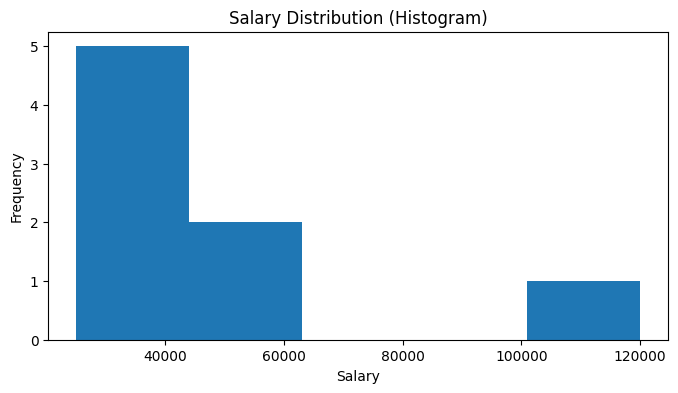

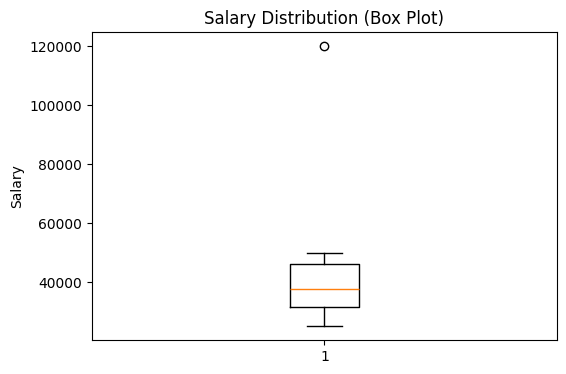

In [26]:
# Exploratory Data Analysis (EDA) - Univariate Analysis

import pandas as pd
import matplotlib.pyplot as plt

# Sample Data
df = pd.DataFrame({
    'salary': [25000, 30000, 32000, 35000, 40000, 45000, 50000, 120000]
})

# Summary Statistics
print("Summary Statistics:")
print(df.describe())

# Five-Number Summary
print("\nFive-Number Summary:")
print("Minimum :", df['salary'].min())
print("Q1 (25%):", df['salary'].quantile(0.25))
print("Median  :", df['salary'].median())
print("Q3 (75%):", df['salary'].quantile(0.75))
print("Maximum :", df['salary'].max())

# Histogram
plt.figure(figsize=(8, 4))
plt.hist(df['salary'], bins=5)
plt.title("Salary Distribution (Histogram)")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# Box Plot
plt.figure(figsize=(6, 4))
plt.boxplot(df['salary'])
plt.title("Salary Distribution (Box Plot)")
plt.ylabel("Salary")
plt.show()

In [27]:
# Outlier Detection using IQR (Interquartile Range)

import pandas as pd

# Sample Data
df = pd.DataFrame({
    'values': [10, 15, 20, 25, 30, 35, 40, 50, 100]
})

# Calculate Q1, Q3, and IQR
Q1 = df['values'].quantile(0.25)
Q3 = df['values'].quantile(0.75)
IQR = Q3 - Q1

# Calculate fences
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Detect outliers (strict inequalities)
outliers = df[
    (df['values'] < lower_fence) |
    (df['values'] > upper_fence)
]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Fence =", lower_fence)
print("Upper Fence =", upper_fence)

print("\nOutliers:")
print(outliers)

Q1 = 20.0
Q3 = 40.0
IQR = 20.0
Lower Fence = -10.0
Upper Fence = 70.0

Outliers:
   values
8     100


Correlation Coefficient: 0.9953604884968785


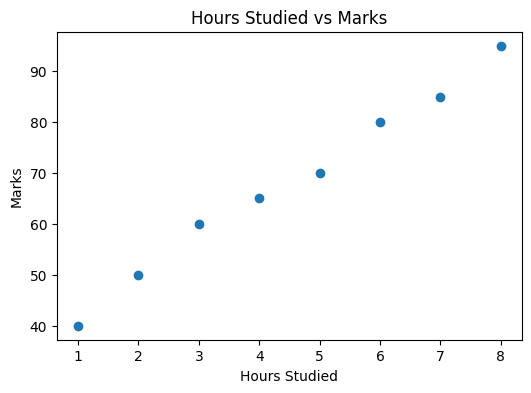

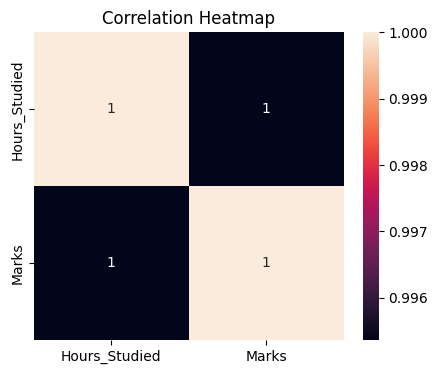

In [28]:
# 10.3 Bivariate Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample Data
df = pd.DataFrame({
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'Marks': [40, 50, 60, 65, 70, 80, 85, 95]
})

# Correlation Coefficient
correlation = df['Hours_Studied'].corr(df['Marks'])
print("Correlation Coefficient:", correlation)

# Scatter Plot
plt.figure(figsize=(6, 4))
plt.scatter(df['Hours_Studied'], df['Marks'])
plt.title("Hours Studied vs Marks")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.show()

# Heatmap of Correlation Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [29]:
# 11.1 Encoding Categorical Variables

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Sample Data
df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', 'blue'],
    'size': ['Small', 'Medium', 'Large', 'Small', 'Large']
})

# ---------------------------
# Label Encoding (Ordinal Data)
# ---------------------------
le = LabelEncoder()
df['size_encoded'] = le.fit_transform(df['size'])

print("Label Encoding:")
print(df)

# ---------------------------
# One-Hot Encoding (Nominal Data)
# ---------------------------
df_onehot = pd.get_dummies(df, columns=['color'])

print("\nOne-Hot Encoding:")
print(df_onehot)

Label Encoding:
   color    size  size_encoded
0    red   Small             2
1   blue  Medium             1
2  green   Large             0
3    red   Small             2
4   blue   Large             0

One-Hot Encoding:
     size  size_encoded  color_blue  color_green  color_red
0   Small             2       False        False       True
1  Medium             1        True        False      False
2   Large             0       False         True      False
3   Small             2       False        False       True
4   Large             0        True        False      False
